# Compare models

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import brier_score_loss

# Visualizations
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [2]:
# Load in the results
gpt2_results = pd.read_csv('gpt2_results.csv')
roberta_results = pd.read_csv('roberta_calibrated_pll_results_fulldata.csv')

In [3]:
print(gpt2_results.describe())
print("")
print(roberta_results.describe())

         confidence
count  10962.000000
mean       0.401175
std        0.127445
min        0.210714
25%        0.309473
50%        0.369221
75%        0.456298
max        0.996386

         confidence
count  10962.000000
mean       0.734239
std        0.191468
min        0.241574
25%        0.570134
50%        0.752006
75%        0.914489
max        0.999991


In [4]:
def compute_basic_metrics(df):
    y_true = df['answerKey']
    y_pred = df['predicted']
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    return acc, f1

def compute_brier(df):
    y_true = df['correct']
    y_prob = df['confidence']
    
    return brier_score_loss(y_true, y_prob)

def compute_ece(df, n_bins=10):
    y_true = df['correct'].values
    y_prob = df['confidence'].values
    
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    
    ece = 0.0
    for i in range(n_bins):
        bin_mask = bin_ids == i
        if np.sum(bin_mask) > 0:
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(df)
    
    return ece


In [5]:
gpt2_acc, gpt2_f1 = compute_basic_metrics(gpt2_results)
roberta_acc, roberta_f1 = compute_basic_metrics(roberta_results)

# Higher is better
print("GPT-2:\nAcc:", gpt2_acc, "\nMacro F1:", gpt2_f1)
print("\nRoBERTa:\nAcc:", roberta_acc, "\nMacro F1:", roberta_f1)

GPT-2:
Acc: 0.2835249042145594 
Macro F1: 0.2821351470047416

RoBERTa:
Acc: 0.2388250319284802 
Macro F1: 0.23747561733807637


In [6]:
gpt2_brier = compute_brier(gpt2_results)
roberta_brier = compute_brier(roberta_results)

# Lower is better
print("GPT-2 Brier:", gpt2_brier) #
print("RoBERTa Brier:", roberta_brier)

GPT-2 Brier: 0.22463732328982888
RoBERTa Brier: 0.46133801307702577


In [7]:
gpt2_ece = compute_ece(gpt2_results)
roberta_ece = compute_ece(roberta_results)

# Lower is better
print("GPT-2 ECE:", gpt2_ece)
print("RoBERTa ECE:", roberta_ece)

GPT-2 ECE: 0.11765026820552782
RoBERTa ECE: 0.4955110007628888


## Figures

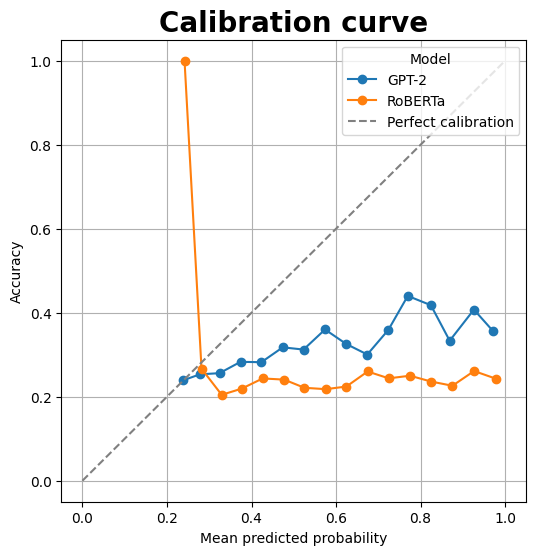

In [14]:
def plot_calibration(df, label, n_bins=20):
    y_true = df['correct']
    y_prob = df['confidence']
    
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    
    plt.plot(prob_pred, prob_true, marker='o', label=label)

plt.figure(figsize=(6,6))

plot_calibration(gpt2_results, "GPT-2")
plot_calibration(roberta_results, "RoBERTa")

plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration', color='gray')

plt.xlabel("Mean predicted probability")
plt.ylabel("Accuracy")
plt.title("Calibration curve", fontsize=20, fontweight="bold")
plt.legend(title='Model', loc='upper right')
plt.grid()

plt.show()

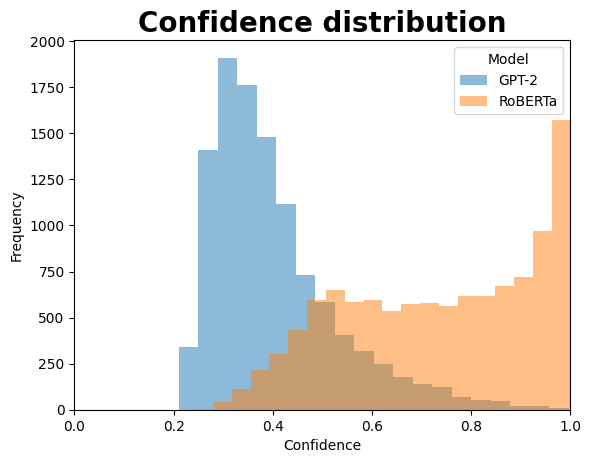

In [10]:
plt.hist(gpt2_results['confidence'], bins=20, alpha=0.5, label='GPT-2')
plt.hist(roberta_results['confidence'], bins=20, alpha=0.5, label='RoBERTa')

plt.xlim(0, 1)
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.legend(title='Model')
plt.title("Confidence distribution", fontsize=20, fontweight="bold")

plt.show()

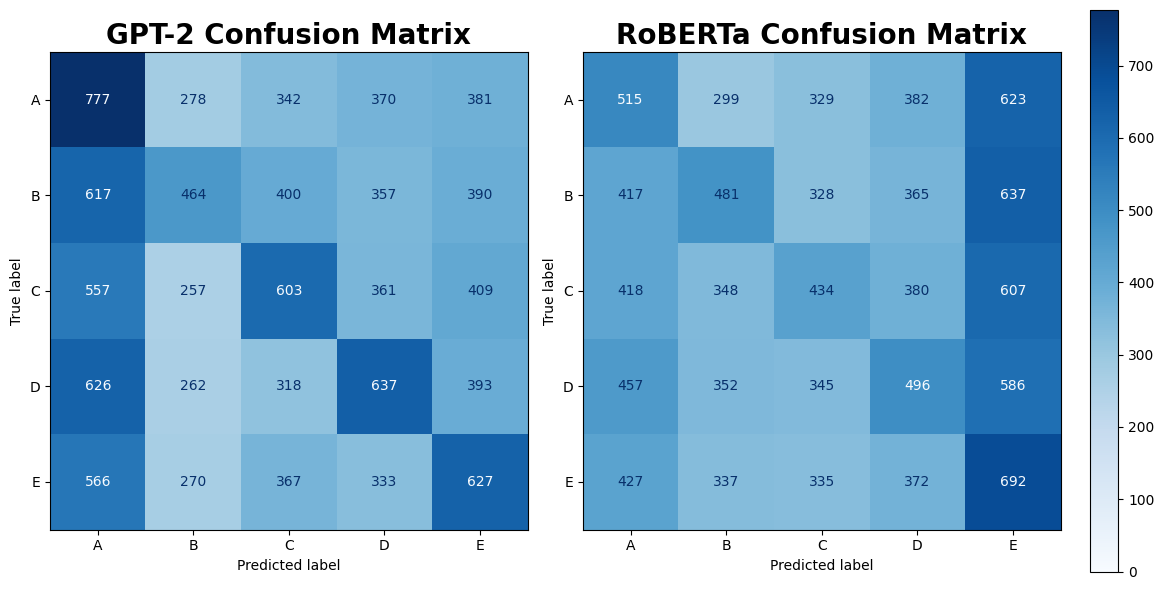

In [11]:
labels = sorted(list(set(gpt2_results['answerKey']) | set(gpt2_results['predicted']) |
                     set(roberta_results['answerKey']) | set(roberta_results['predicted'])))

# Compute confusion matrices
cm_gpt2 = confusion_matrix(gpt2_results['answerKey'], gpt2_results['predicted'], labels=labels)
cm_roberta = confusion_matrix(roberta_results['answerKey'], roberta_results['predicted'], labels=labels)
vmax = max(cm_gpt2.max(), cm_roberta.max())

fig, axes = plt.subplots(1, 2, figsize=(12,6),gridspec_kw={'width_ratios':[4,5]})

# GPT-2
disp_gpt2 = ConfusionMatrixDisplay(confusion_matrix=cm_gpt2, display_labels=labels)
disp_gpt2.plot(ax=axes[0], cmap='Blues', colorbar=False)
disp_gpt2.im_.set_clim(0, vmax)
axes[0].set_title("GPT-2 Confusion Matrix", fontsize=20, fontweight="bold")

# RoBERTa
disp_roberta = ConfusionMatrixDisplay(confusion_matrix=cm_roberta, display_labels=labels)
disp_roberta.plot(ax=axes[1], cmap='Blues', colorbar=True)
disp_roberta.im_.set_clim(0, vmax)
axes[1].set_title("RoBERTa Confusion Matrix", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.show()

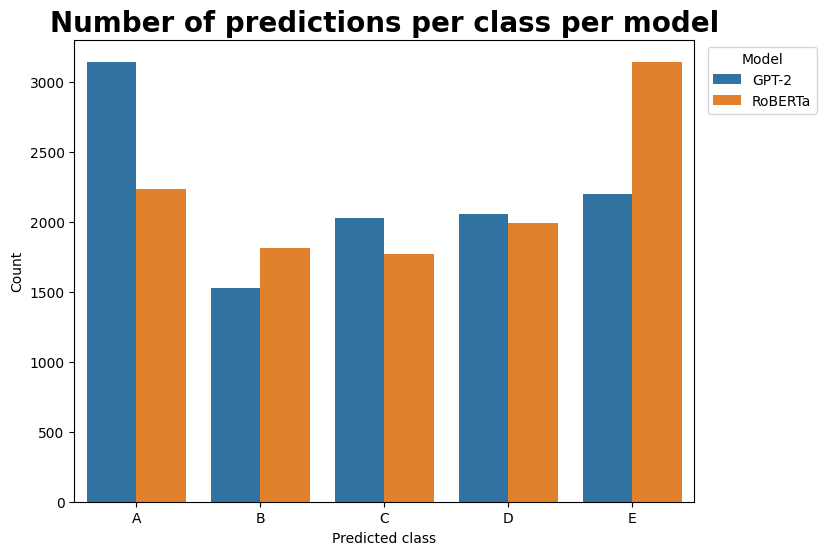

In [12]:
# add model label
gpt2_results['model'] = 'GPT-2'
roberta_results['model'] = 'RoBERTa'

# combine datasets
df_all = pd.concat([gpt2_results, roberta_results], ignore_index=True)

# count per predicted class per model
pred_counts = df_all.groupby(['model', 'predicted']).size().reset_index(name='count')

plt.figure(figsize=(8,6))

sns.barplot(
    x='predicted',
    y='count',
    hue='model',
    data=pred_counts,
    alpha=1, 
    order=sorted(df_all['predicted'].unique())  # alphabetical order
)

plt.title("Number of predictions per class per model", fontsize=20, fontweight="bold")
plt.xlabel("Predicted class")
plt.ylabel("Count")
plt.legend(title='Model', bbox_to_anchor=(1.01,1))
plt.show()

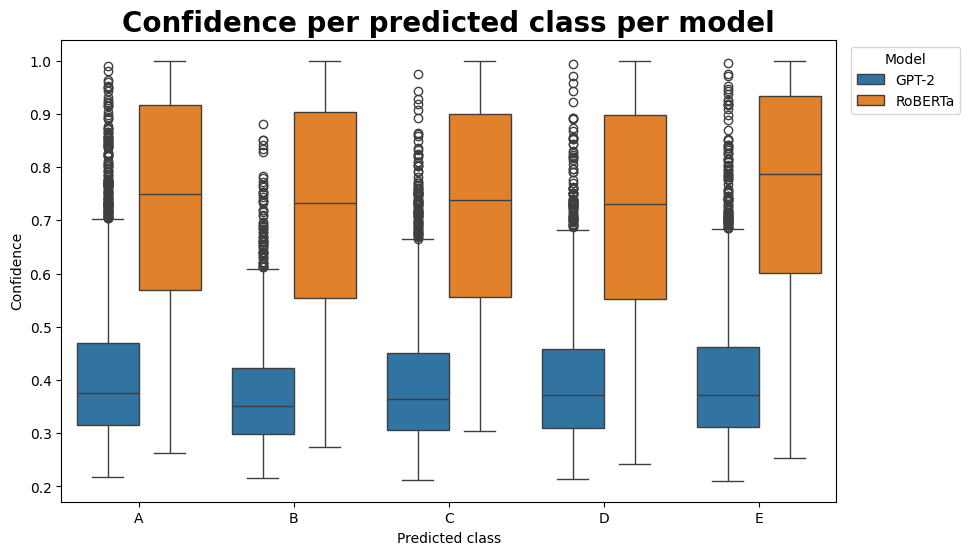

In [13]:


plt.figure(figsize=(10,6))

# grouped boxplot
sns.boxplot(x='predicted', y='confidence', hue='model', 
            boxprops={'alpha':1}, 
        order=sorted(df_all['predicted'].unique()),
            data=df_all)

plt.title("Confidence per predicted class per model", fontsize=20, fontweight="bold")
plt.xlabel("Predicted class")
plt.ylabel("Confidence")
plt.legend(title='Model', bbox_to_anchor=(1.01, 1))
plt.show()